In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns

In [2]:
sns.set()
breast_cancer_data = load_breast_cancer()
X_df = pd.DataFrame(breast_cancer_data.data, columns =
breast_cancer_data.feature_names)
X_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X_df = X_df[["mean area", "mean compactness"]]
X_df.head()

,mean area,mean compactness
0,1001.0,0.27760
1,1326.0,0.07864
2,1203.0,0.15990
3,386.1,0.28390
4,1297.0,0.13280


In [4]:
Y_df = pd.Categorical.from_codes(breast_cancer_data.target,
breast_cancer_data.target_names)
print(Y_df)

['malignant', 'malignant', 'malignant', 'malignant', 'malignant', ..., 'malignant', 'malignant', 'malignant', 'malignant', 'benign']
Length: 569
Categories (2, object): ['malignant', 'benign']


In [5]:
Y_df = pd.get_dummies(Y_df, drop_first=True)
print(Y_df)

     benign
0     False
1     False
2     False
3     False
4     False
..      ...
564   False
565   False
566   False
567   False
568    True

[569 rows x 1 columns]


In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(X_df, Y_df, random_state=1)
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn.fit(X_train, Y_train)

C:\Users\jeeva\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(metric='euclidean')

<Axes: xlabel='mean area', ylabel='mean compactness'>

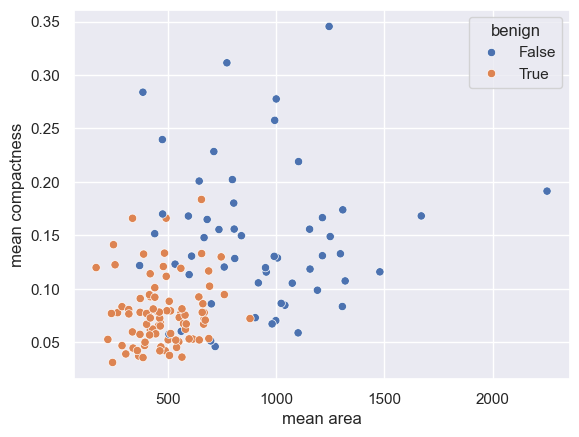

In [7]:
combined_df = pd.concat([X_test, Y_test], axis=1)
sns.scatterplot(x="mean area", y="mean compactness", hue="benign", data = combined_df)

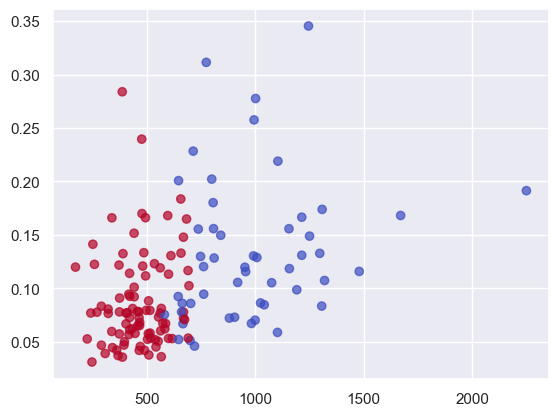

In [8]:
Y_pred = knn.predict(X_test)
plt.scatter(X_test["mean area"], X_test["mean compactness"], c=Y_pred, cmap="coolwarm",
alpha=0.7)

In [9]:
cf = confusion_matrix(Y_test, Y_pred)
print(cf)


[[42 13]
 [ 9 79]]


[Text(0, 0.5, 'Malignant'), Text(0, 1.5, 'Benign')]

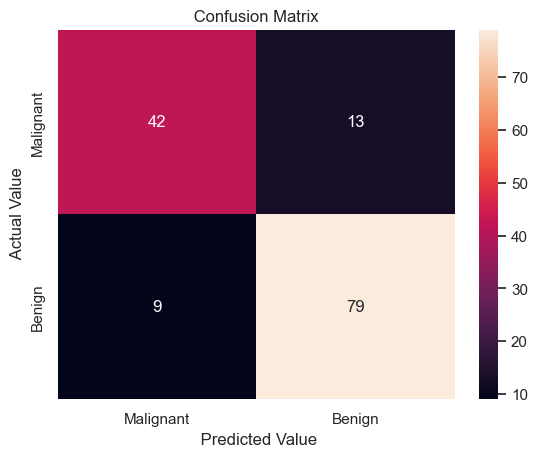

In [10]:
labels = ["True Negative", "False Positive", "False Negative", "True Positive"]
labels = np.asarray(labels).reshape(2,2)
categories = ["Zero", "One" ]
ax = plt.subplot()
sns.heatmap(cf, annot=True, ax=ax)
ax.set_xlabel(" Predicted Value")
47
ax.set_ylabel(" Actual Value")
ax.set_title(" Confusion Matrix ")
ax.xaxis.set_ticklabels(["Malignant", "Benign"])
ax.yaxis.set_ticklabels(["Malignant", "Benign"])

In [11]:
tp,fn,fp,tn = confusion_matrix(Y_test, Y_pred, labels=[1,0]).reshape(-1)
print(tp,fn,fp,tn)

79 9 13 42


In [12]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
print("Accuracy :", accuracy)

Accuracy : 0.8461538461538461


In [13]:
precision = tp / (tp + fp)
print("Precision :", precision)

Precision : 0.8586956521739131


In [14]:
recall = tp / (tp + fn)
print("Recall :", recall)


Recall : 0.8977272727272727


In [15]:
f1_score = 2 * (precision * recall) / (precision + recall)
print("F1 Score :", f1_score)


F1 Score : 0.8777777777777778
